# Preprocessing

In [2]:
import os
import sys
from tqdm import tqdm 
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
import torchvision.utils as vutils
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
sys.path.append(os.path.abspath('../../src/dataset'))
from paired_image_dataset import PairedImageDataset

DATA_DIR = os.path.join('..', '..', 'data')
print(os.listdir(DATA_DIR))

['all', 'cnn', 'h_blur', 'low_light']


In [4]:
image_width = 256
image_height = 128
batch_size = 32
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

In [8]:
train_transform = T.Compose([
    T.Resize((image_height, image_width)),
    T.ToTensor(),
    T.Normalize(*stats)])

valid_transform = T.Compose([
    T.Resize((image_height, image_width)),
    T.ToTensor(),
    T.Normalize(*stats)
])

In [10]:
train_ds = PairedImageDataset(blur_dir=os.path.join(DATA_DIR, 'low_light', 'train', 'low_light'), 
                              normal_dir=os.path.join(DATA_DIR, 'low_light', 'train', 'enhanced'),
                              transform=train_transform)

valid_ds = PairedImageDataset(blur_dir=os.path.join(DATA_DIR, 'low_light', 'valid', 'low_light'), 
                              normal_dir=os.path.join(DATA_DIR, 'low_light', 'valid', 'enhanced'),
                              transform=valid_transform)

In [12]:
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
valid_dl = DataLoader(valid_ds, batch_size=32*2, shuffle=True, num_workers=4)

### Helper functions

In [14]:
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

def show_images(input_images, target_images, nmax=16):
    input_images = denorm(input_images.detach()[:nmax])
    target_images = denorm(target_images.detach()[:nmax])

    # Combine into a single tensor for visualization
    combined = torch.cat((input_images, target_images), 0)
    grid = make_grid(combined, nrow=nmax)

    plt.figure(figsize=(nmax // 2, 4))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title("Top: Low-light / Blurred | Bottom: Normal / Target")
    plt.show()

def show_batch(dl, nmax=16):
    for input_batch, target_batch in dl:
        show_images(input_batch, target_batch, nmax)
        break

In [16]:
def show_paired_samples(dataset, num_samples=4):
    fig, axes = plt.subplots(num_samples, 2, figsize=(5, 2 * num_samples))

    for i in range(num_samples):
        input_img, target_img = dataset[i]

        input_img = denorm(input_img)
        target_img = denorm(target_img)

        if isinstance(input_img, torch.Tensor):
            input_img = input_img.permute(1, 2, 0).numpy()
            target_img = target_img.permute(1, 2, 0).numpy()

        axes[i, 0].imshow(input_img)
        axes[i, 0].set_title("Low Light (Input)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(target_img)
        axes[i, 1].set_title("Normal (Target)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

def show_generated_images(images, nrow=4):
    images = denorm(images.detach().cpu())

    # Make grid
    grid_img = vutils.make_grid(images, nrow=nrow, normalize=False)

    # Show image
    plt.figure(figsize=(nrow * 2, 2 * (len(images) // nrow)))
    plt.axis('off')
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.show()

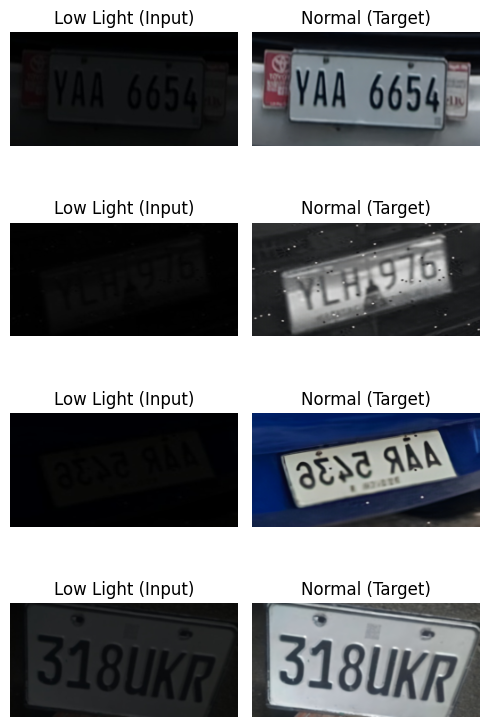

In [47]:
show_paired_samples(train_ds)

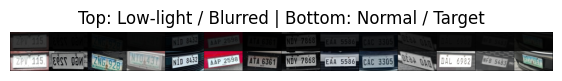

In [101]:
show_batch(train_dl, nmax=14)

In [18]:
def print_images(image_tensor, num_images):
    images = denorm(image_tensor)
    images = images.detach().cpu()
    image_grid = make_grid(images[:num_images], nrow=5)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.show()

In [20]:
def save_samples(index, gen_image, show=True):
    fake_images = generator(latent_tensors)
    fake_fname = 'generated-images-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=8)
    print('Saving', fake_fname)
    if show:
        fig, ax = plt.subplots(figsize=(8,8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(fake_images.cpu().detach(), nrow=8).permute(1, 2, 0))

### Setup GPU

In [22]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

In [24]:
device = get_default_device()
device

device(type='cuda')

In [26]:
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)

# Building the Model

In [29]:
class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4):
        super(DownSample, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, 
                      stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4):
        super(UpSample, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, 
                               stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value = nn.Conv2d(in_channels, in_channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.size()
        proj_query = self.query(x).view(B, -1, H * W).permute(0, 2, 1)
        proj_key = self.key(x).view(B, -1, H * W)
        attention = torch.bmm(proj_query, proj_key)
        attention = torch.softmax(attention, dim=-1)

        proj_value = self.value(x).view(B, -1, H * W)
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(B, C, H, W)

        return self.gamma * out + x

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)

### Generator

In [31]:
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(Generator, self).__init__()

        # Encoder (Downsampling)
        self.down1 = DownSample(in_channels, 64)  # -> (64, 64, 128)
        self.down2 = DownSample(64, 128)          # -> (128, 32, 64)
        self.down3 = DownSample(128, 256)         # -> (256, 16, 32)
        self.down4 = DownSample(256, 512)         # -> (512, 8, 16)
        self.down5 = DownSample(512, 1024)        # -> (1024, 4, 8)
        self.down6 = DownSample(1024, 1024)       # -> (1024, 2, 4)
        
        # Bottleneck with attention and residual
        self.attn = SelfAttention(1024)
        self.res = ResidualBlock(1024)
        
        # Decoder (Upsampling)
        self.up1 = UpSample(1024, 1024)           # -> (1024, 4, 8)
        self.up2 = UpSample(2048, 512)           # -> (1024, 8, 16)
        self.up3 = UpSample(1024, 256)            # -> (512, 16, 32)
        self.up4 = UpSample(512, 128)            # -> (256, 32, 64)
        self.up5 = UpSample(256, 64)             # -> (128, 64, 128)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1), # -> (64, 128, 256)
            nn.Tanh()
        )

    def forward(self, x):
        # U-Net generator with skip connections from encoder to decoder
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)

        bottleneck = self.attn(d6)
        bottleneck = self.res(bottleneck)
        
        u1 = self.up1(bottleneck, d5)
        u2 = self.up2(u1, d4)
        u3 = self.up3(u2, d3)
        u4 = self.up4(u3, d2)
        u5 = self.up5(u4, d1)
        u6 = self.final(u5)
        return u6

In [33]:
image = torch.rand((1, 3, 128, 256))
out_channels = 3
generator = Generator()
output = generator(image)
print(output.shape)

torch.Size([1, 3, 128, 256])


### Discriminator

In [37]:
def conv_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=bias),
        nn.LeakyReLU(0.2, inplace=True)
    )

In [39]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=6, kernel_size=4):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            conv_block(in_channels, 64), # 128x256
            conv_block(64, 128), # 64x128
            conv_block(128, 256), # 32x64
            conv_block(256, 512), # 16x32
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1, bias=False) # 8x16
        )

    def forward(self, image1, image2):
        img_input = torch.cat((image1, image2), 1)
        return self.model(img_input)

In [41]:
image1 = torch.rand((1, 3, 128, 256))
image2 = torch.rand((1, 3, 128, 256))

out_channels = 3
discriminator = Discriminator()
output = discriminator(image1, image2)
print(output.shape)

torch.Size([1, 1, 8, 16])


# Training

In [43]:
discriminator = to_device(discriminator, device)
generator = to_device(generator, device)

### Defining loss functions

In [46]:
comparison_loss = nn.BCEWithLogitsLoss()
L1_loss = nn.L1Loss()

### Discriminator training function

In [48]:
def train_discriminator(discriminator, inputs, targets, opt_d):
    # Clear discriminator gradients
    opt_d.zero_grad()

    # Pass real image
    real_preds = discriminator(inputs, targets)
    real_targets = torch.ones(size=real_preds.shape, dtype=torch.float, device=device)
    real_loss = comparison_loss(real_preds, real_targets)
    real_score = torch.mean(real_preds).item()

    # Generate fake image
    fake_image = generator(inputs).detach()
    fake_preds = discriminator(inputs, fake_image)
    fake_label = torch.zeros(size=fake_preds.shape, dtype=torch.float, device=device)
    fake_loss = comparison_loss(fake_preds, fake_label)
    fake_score = torch.mean(fake_preds).item()

    # Total loss
    loss = (real_loss + fake_loss) / 2

    # Update discriminator weights
    loss.backward()
    opt_d.step()

    return loss, real_score, fake_score

### Generator training function

In [51]:
!pip install pytorch-msssim --quiet


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from pytorch_msssim import ssim as ssim_fn

def ssim_loss(pred, target):
    return 1 - ssim_fn(pred, target, data_range=1.0, size_average=True)

In [55]:
def train_generator(generator, inputs, targets, opt_g, L1_lambda, perceptual_weight=None, ssim_lambda=1.0):
    # Clear generator gradients
    opt_g.zero_grad()

    # Generate image
    gen_image = generator(inputs)
    d_output = discriminator(inputs, gen_image)
    desired_output = torch.ones(size=d_output.shape, dtype=torch.float, device=device)

    # Update generator weights
    loss = comparison_loss(d_output, desired_output) + L1_lambda * torch.abs(gen_image-targets).sum() + ssim_lambda * ssim_loss(gen_image, targets)
    loss.backward()
    opt_g.step()

    return loss, gen_image

### Hyperparameter configurations

In [59]:
L1_lambda = 100
epochs = 10
lr = 0.0002
beta1 = 0.5
beta2 = 0.999

opt_g = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
opt_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))

In [61]:
from torchmetrics.image.psnr import PeakSignalNoiseRatio
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure
from torchmetrics.image.fid import FrechetInceptionDistance

In [62]:
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
fid_metric = FrechetInceptionDistance(feature=2048).to(device)

In [63]:
def to_uint8(tensor):
    # Clamp to [0, 1], scale to [0, 255], then convert to uint8
    tensor = torch.clamp(tensor, 0.0, 1.0)
    tensor = (tensor * 255.0).to(torch.uint8)
    return tensor

In [64]:
@torch.no_grad()
def evaluate_generator(generator, valid_dl, epoch):
    generator.eval()
    psnr_vals = []
    ssim_vals = []
    fid_metric.reset()

    with torch.no_grad():
        for val_inputs, val_targets in valid_dl:
            val_inputs = val_inputs.to(device)
            val_targets = val_targets.to(device)

            val_outputs = generator(val_inputs)

            # Convert to uint8 for FID
            gen_uint8 = to_uint8(val_outputs)
            target_uint8 = to_uint8(val_targets)
        
            fid_metric.update(gen_uint8, real=False)
            fid_metric.update(target_uint8, real=True)

            # Compute PSNR/SSIM
            psnr = psnr_metric(val_outputs, val_targets).item()
            ssim = ssim_metric(val_outputs, val_targets).item()
            psnr_vals.append(psnr)
            ssim_vals.append(ssim)
        
    mean_psnr = sum(psnr_vals) / len(psnr_vals)
    mean_ssim = sum(ssim_vals) / len(ssim_vals)
    fid = fid_metric.compute().item()
    
    print(f"Epoch [{epoch+1}/{epochs}] - Mean PSNR: {mean_psnr:.4f}, Mean SSIM: {mean_ssim:.4f}, FID: {fid}")
    return mean_psnr, mean_ssim, fid

def fit(generator, discriminator, epochs, lr, perceptual_weight=None, opt_g=None, opt_d=None, checkpoint=None):
    torch.cuda.empty_cache()

    # Losses and scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []
    psnrs = []
    ssims = []
    fids = []

    # Create optimizers
    if opt_d is None:
        opt_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    if opt_g is None:
        opt_g = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))

    # Load checkpoint state if resuming
    if checkpoint is not None:
        print("Resuming training from checkpoint...")
        opt_d.load_state_dict(checkpoint['opt_d_state_dict'])
        opt_g.load_state_dict(checkpoint['opt_g_state_dict'])

    # Train
    for epoch in range(epochs):
        generator.train()
        for inputs, targets in tqdm(train_dl):
            
            # Splitting the image
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Train discriminator
            loss_d, real_score, fake_score = train_discriminator(discriminator, inputs, targets, opt_d)

            # Train generator
            for i in range(2):
                loss_g, gen_image = train_generator(generator, inputs, targets, opt_g, L1_lambda)

        print_images(inputs, 5)
        print_images(gen_image, 5)
        print_images(targets, 5)

        # log losses & scores (last batch)
        try:
            print('Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}'.format( 
                  epoch+1, epochs, loss_g, loss_d, real_score, fake_score))
        except:
            print('Error')

        mean_psnr, mean_ssim, fid = evaluate_generator(generator, valid_dl, epoch)

        # Record losses and scores
        losses_g.append(loss_g)
        losses_d.append(loss_d)
        real_scores.append(real_score)
        fake_scores.append(fake_score)
        psnrs.append(mean_psnr)
        ssims.append(mean_ssim)
        fids.append(fid)

    return losses_g, losses_d, real_scores, fake_scores, psnrs, ssims, fids

In [69]:
history = []

100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:54<00:00,  1.59it/s]


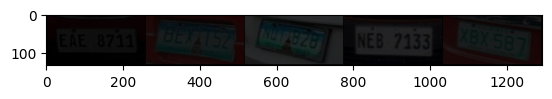

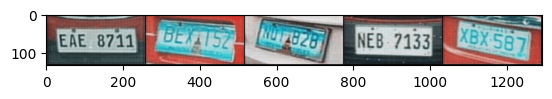

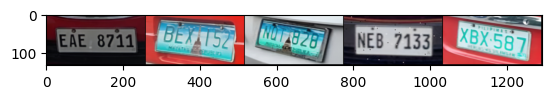

Epoch [1/10], loss_g: 18564938.0000, loss_d: 0.5612, real_score: 1.4841, fake_score: -0.2788
Epoch [1/10] - Mean PSNR: 12.7553, Mean SSIM: 0.5462, FID: 70.86885070800781


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:52<00:00,  1.60it/s]


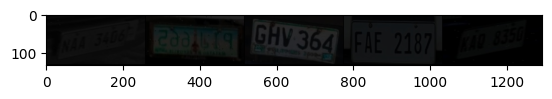

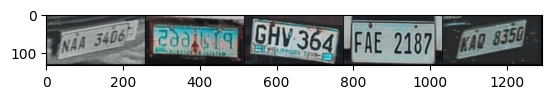

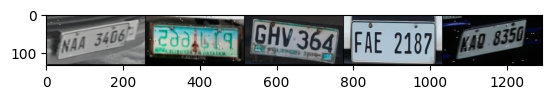

Epoch [2/10], loss_g: 15436990.0000, loss_d: 0.2020, real_score: 3.4748, fake_score: -1.4347
Epoch [2/10] - Mean PSNR: 13.3645, Mean SSIM: 0.5625, FID: 62.40035629272461


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:49<00:00,  1.62it/s]


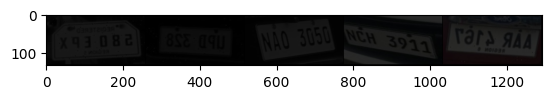

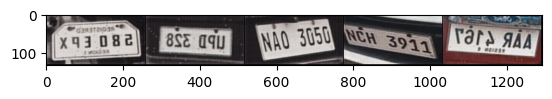

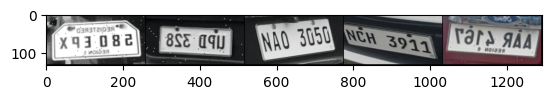

Epoch [3/10], loss_g: 13948470.0000, loss_d: 0.0201, real_score: 5.7435, fake_score: -6.7738
Epoch [3/10] - Mean PSNR: 13.9497, Mean SSIM: 0.6206, FID: 57.78084182739258


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:48<00:00,  1.63it/s]


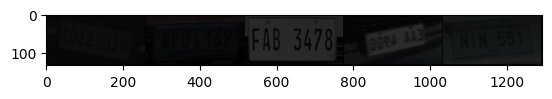

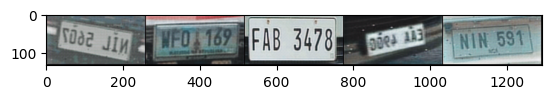

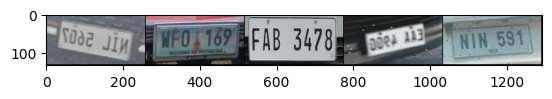

Epoch [4/10], loss_g: 10618521.0000, loss_d: 0.0073, real_score: 11.0193, fake_score: -10.4938
Epoch [4/10] - Mean PSNR: 13.8963, Mean SSIM: 0.6006, FID: 55.328121185302734


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:48<00:00,  1.63it/s]


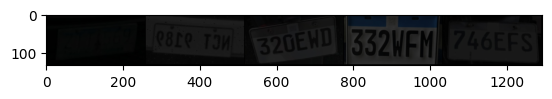

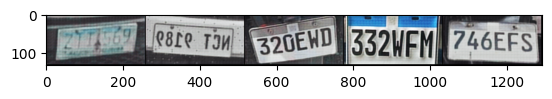

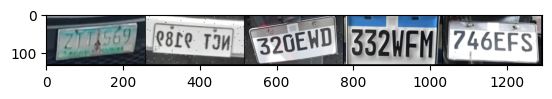

Epoch [5/10], loss_g: 16158680.0000, loss_d: 0.0278, real_score: 7.6413, fake_score: -10.3533
Epoch [5/10] - Mean PSNR: 14.2202, Mean SSIM: 0.6216, FID: 68.18843841552734


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:48<00:00,  1.63it/s]


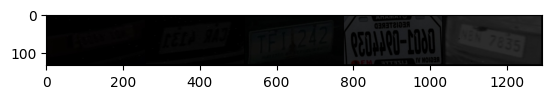

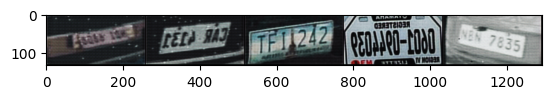

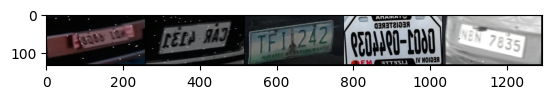

Epoch [6/10], loss_g: 16063101.0000, loss_d: 0.0144, real_score: 7.1167, fake_score: -11.3347
Epoch [6/10] - Mean PSNR: 11.4004, Mean SSIM: 0.5075, FID: 64.5802001953125


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:48<00:00,  1.63it/s]


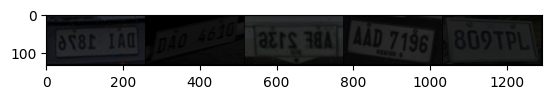

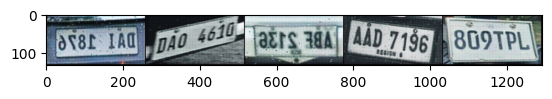

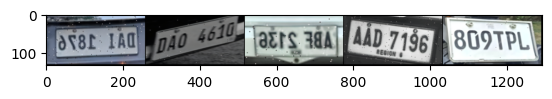

Epoch [7/10], loss_g: 13499417.0000, loss_d: 0.1640, real_score: 2.0307, fake_score: -8.2212
Epoch [7/10] - Mean PSNR: 15.0325, Mean SSIM: 0.6449, FID: 59.36064529418945


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:48<00:00,  1.63it/s]


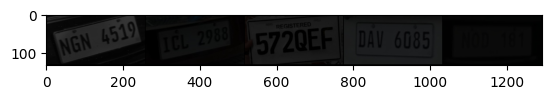

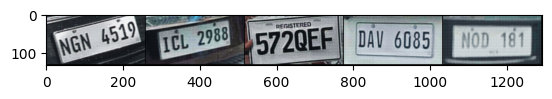

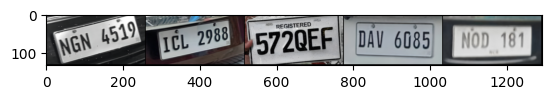

Epoch [8/10], loss_g: 13784782.0000, loss_d: 0.0077, real_score: 7.7124, fake_score: -10.3264
Epoch [8/10] - Mean PSNR: 15.0150, Mean SSIM: 0.6393, FID: 59.25486373901367


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:50<00:00,  1.61it/s]


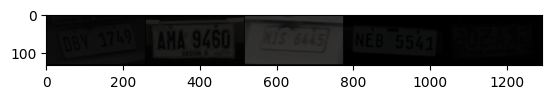

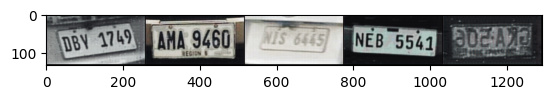

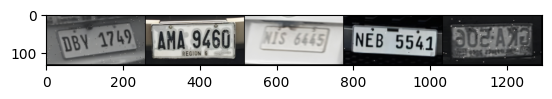

Epoch [9/10], loss_g: 11942577.0000, loss_d: 0.0084, real_score: 7.3633, fake_score: -12.2048
Epoch [9/10] - Mean PSNR: 14.3066, Mean SSIM: 0.6396, FID: 50.71675109863281


100%|████████████████████████████████████████████████████████████████████████████████| 372/372 [03:48<00:00,  1.63it/s]


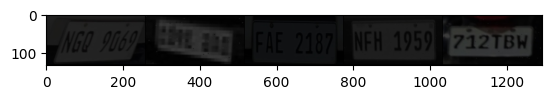

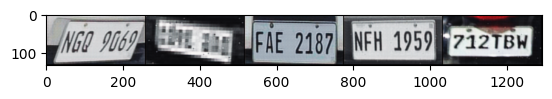

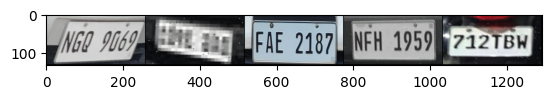

Epoch [10/10], loss_g: 11224792.0000, loss_d: 0.0174, real_score: 7.6356, fake_score: -9.0463
Epoch [10/10] - Mean PSNR: 15.4163, Mean SSIM: 0.6493, FID: 59.23672866821289
CPU times: total: 43min 15s
Wall time: 41min 25s


In [71]:
%%time
history += fit(generator, discriminator, epochs, lr, opt_g=opt_g, opt_d=opt_d)

In [73]:
torch.cuda.empty_cache()

# Save model

In [75]:
torch.save(generator.state_dict(), "generator-attention-L1-Sum-SSIM-10epoch.pt")
torch.save(discriminator.state_dict(), "discrimininator-attention-L1-Sum-SSIM-10epoch.pt")

In [77]:
torch.save({
    'generator_state_dict': generator.state_dict(),
    'discriminator_state_dict': discriminator.state_dict(),
    'opt_g_state_dict': opt_g.state_dict(),
    'opt_d_state_dict': opt_d.state_dict(),
    'history': history
}, f'checkpoin-attention-L1-Sum-SSIM-10epoch.pt')

### Load model

In [135]:
generator = Generator()
loaded_g_wts = torch.load(os.path.join('generator-L1-Sum-SSIM-50epoch.pt'))
generator.load_state_dict(loaded_g_wts)
generator = to_device(generator, device)

discriminator = Discriminator()
loaded_d_wts = torch.load(os.path.join('discrimininator-L1-Sum-SSIM-50epoch.pt'))
discriminator.load_state_dict(loaded_d_wts)
discriminator = to_device(discriminator, device)

In [139]:
checkpoint = torch.load('checkpoint-L1-Sum-SSIM-50epoch.pt')
opt_g.load_state_dict(checkpoint['opt_g_state_dict'])
opt_d.load_state_dict(checkpoint['opt_d_state_dict'])

# Model evaluation

In [ ]:
!pip install torchmetrics pytorch-fid torch-fidelity torchmetrics[image]

In [79]:
psnr_vals = []
ssim_vals = []

fid_metric = FrechetInceptionDistance(feature=2048).to(device)
fid_metric.reset()

generator.eval()
for val_input, val_target in valid_dl:
    val_input = val_input.to(device)
    val_target = val_target.to(device)

    with torch.no_grad():
        gen_output = generator(val_input)

    # Convert to uint8 for FID
    gen_uint8 = to_uint8(gen_output)
    target_uint8 = to_uint8(val_target)

    fid_metric.update(gen_uint8, real=False)
    fid_metric.update(target_uint8, real=True)

    #show_generated_images(gen_output)

    # Compute PSNR/SSIM
    psnr = psnr_metric(gen_output, val_target).item()
    ssim = ssim_metric(gen_output, val_target).item()
    psnr_vals.append(psnr)
    ssim_vals.append(ssim)

print("Mean PSNR:", sum(psnr_vals) / len(psnr_vals))
print("Mean SSIM:", sum(ssim_vals) / len(ssim_vals))
print("FID:", fid_metric.compute().item())

Mean PSNR: 15.38181482042585
Mean SSIM: 0.6496484364782061
FID: 59.23784637451172


### Custom image test

In [87]:
def deblur_image(image_path, generator, device):
    image = Image.open(image_path).convert('RGB')
    input_tensor = valid_transform(image).unsqueeze(0).to(device)

    generator.eval()
    with torch.no_grad():
        gen_image = generator(input_tensor)

    output = denorm(gen_image.squeeze(0).cpu())

    plt.imshow(output.permute(1, 2, 0))  # CHW → HWC
    plt.axis('off')
    plt.title("Generated Image")
    plt.show()

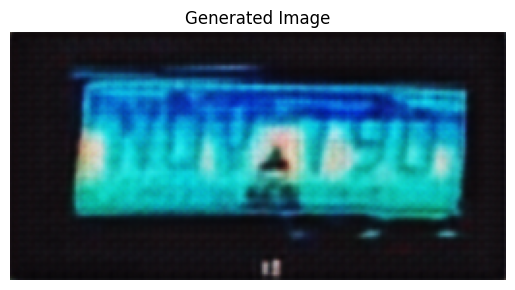

In [101]:
deblur_image(os.path.join(DATA_DIR, 'all', 'test', 'low_light', '37.jpg'), generator, device)

In [84]:
total_params = sum(p.numel() for p in generator.parameters())
total_params

87173380